# Séminaire 8 : Tri et recherche

**Université de Genève — Algorithmique & structures de données**

---

> **Book reference:** Week 8 follows **Chapter 5** of [*Problem Solving with Algorithms and Data Structures using Python*](https://runestone.academy/ns/books/published/pythonds/SortSearch/toctree.html). Reading it alongside the seminar is strongly recommended.

Ce notebook est **volontairement long** : vous pouvez lire à votre rythme, relancer les animations et essayer les exercices. **On ne vous demande pas de mémoriser chaque détail d'implémentation** — concentrez-vous sur *ce que fait chaque algorithme*, *quand l'utiliser* et *à quelle vitesse il fonctionne* en termes larges (par exemple « lent quadratique » versus « rapide n log n »).
 
## Objectifs d'apprentissage

À la fin de ce séminaire vous devriez être capable de :

- Implémenter et expliquer **tri à bulles**, **tri par sélection**, **tri par insertion**, **tri fusion** et **tri rapide** à un niveau élevé (les idées et les versions Python typiques utilisées ici)
- Décrire les complexités temporelles (**meilleur cas / cas moyen / pire cas**) en mots et les relier au tableau de comparaison de la section 1.1
- Expliquer la **stabilité** et savoir quels tris ci-dessus sont stables
- Implémenter la **recherche linéaire** et la **recherche binaire** et savoir quand chacune s'applique
- Utiliser les **`sorted()`**, **`.sort()`** de Python et un **`key=`** pour trier des données réelles

**Optionnel / extension (utile mais pas indispensable pour l'examen) :** le tri de Shell et les graphiques de temps de la section 1.8 — survolez ou sautez si vous préférez un chemin plus doux.

---

## Partie 1 : Théorie

### 1.1 Pourquoi le tri est important

Mettre des éléments en ordre est l'une des opérations les plus courantes en programmation. Cela importe parce que :

- **Recherche binaire** ne fonctionne que sur des données triées — vous divisez l'espace de recherche par deux à chaque étape
- **Déduplication** — trier, puis scanner pour trouver des voisins qui se répètent
- **Présentation** — noms, notes, dates dans un ordre compréhensible

**Stabilité :** si deux lignes **s'égalisent** sur la clé de tri (même note, même clé), un tri **stable** conserve leur **ordre d'origine** ; un tri instable peut mélanger les égalités.

Le tableau ci-dessous est une **fiche de référence** — vous reconnaîtrez ces formes à partir du séminaire et des diapositives.

| Algorithm | Time (Best) | Time (Avg) | Time (Worst) | Space | Stable? |
|-----------|------------|-----------|-------------|-------|--------|
| Bubble Sort | O(n) | O(n²) | O(n²) | O(1) | Yes |
| Selection Sort | O(n²) | O(n²) | O(n²) | O(1) | No |
| Insertion Sort | O(n) | O(n²) | O(n²) | O(1) | Yes |
| Merge Sort | O(n log n) | O(n log n) | O(n log n) | O(n) | Yes |
| Quick Sort | O(n log n) | O(n log n) | O(n²) | O(log n) | No |

> **Astuce :** N'essayez pas de mémoriser ce tableau maintenant. Parcourez d'abord §§1.2–1.6 — les chiffres auront beaucoup plus de sens après avoir vu chaque algorithme en action.

In [28]:
# Libraries used in this notebook:
# - matplotlib: optional timing plots (section 1.8)
# - numpy / ipywidgets / IPython.display: some visualisations if you extend the notebook
# - time, random, copy: exercises and demos

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import ipywidgets as widgets
from IPython.display import display, clear_output
import time
import random
import copy


Les cellules de code de la Partie 1 montrent des **implémentations fonctionnelles** que vous pouvez exécuter et modifier. Pour le cours, visez à **expliquer les étapes avec vos propres mots** ; vous n'avez pas à retenir chaque ligne de chaque fonction d'aide.

### 1.2 Tri à bulles

Le tri à bulles parcourt la liste à plusieurs reprises, compare des éléments adjacents et les échange s'ils sont dans le mauvais ordre. Après chaque passe, le plus grand élément non trié « remonte » à sa position correcte à la fin.

**Complexité temporelle :**
- Meilleur : O(n) avec optimisation d'arrêt anticipé (liste déjà triée)
- Moyen / Pire : O(n²)

**Espace :** O(1) en place  
**Stable :** Oui — les éléments égaux ne sont jamais échangés

> **Remarque sur `record_steps` :** Les fonctions de tri des §§1.2–1.4 acceptent un paramètre optionnel `record_steps=False`. Celui-ci capture des instantanés intermédiaires utilisés uniquement par la démo de temporisation optionnelle de la §1.8. Lorsque vous appelez ces fonctions vous-même (par ex. dans les exercices), passez simplement la liste — vous pouvez ignorer `record_steps`.

![Animation du tri à bulles](../../_static/gifs/bubble_sort.gif)
*Animation : des échanges adjacents font progressivement remonter le plus grand élément vers la fin.*

In [29]:
def bubble_sort(values, record_steps=False):
    """
    Bubble Sort: repeatedly compare neighbours; larger values drift right ("bubble up").

    Parameters
    ----------
    values       : list to sort
    record_steps : if True, also return a list of snapshots for animations

    Time:  O(n²) average/worst, O(n) best when a pass finds no swaps (already sorted)
    Space: O(1) extra beyond the list we sort
    """
    num_values = len(values)
    steps = []               # Only filled when record_steps=True

    # Step 1: outer passes across the list
    for pass_index in range(num_values):
        did_swap = False
        # Step 2: compare neighbouring values in the unsorted range
        for left_index in range(0, num_values - pass_index - 1):
            if record_steps:
                steps.append((values.copy(), (left_index, left_index + 1), pass_index))
            if values[left_index] > values[left_index + 1]:
                values[left_index], values[left_index + 1] = values[left_index + 1], values[left_index]
                did_swap = True
        # Step 3: after each pass, the largest unsorted value is fixed at the end
        # Step 4: if no swap happened, list is already sorted
        if not did_swap:
            break

    return (values, steps) if record_steps else values


sample = [64, 34, 25, 12, 22, 11, 90]
sorted_result, steps = bubble_sort(sample, record_steps=True)
print(f"Input:  {sample}")
print(f"Sorted: {sorted_result}")
print(f"Total comparison steps recorded: {len(steps)}")


Input:  [64, 34, 25, 12, 22, 11, 90]
Sorted: [11, 12, 22, 25, 34, 64, 90]
Total comparison steps recorded: 21


### 1.3 Tri par sélection

Pensez à la liste comme à deux morceaux collés, gauche et droite :

- **Préfixe trié (le morceau gauche) :** indices que vous avez **déjà terminés** — ces valeurs sont à leur place **définitive** et l'algorithme ne les touchera **plus jamais**.
- **Suffixe non trié (le morceau droit) :** le reste de la liste — la partie que vous êtes **encore en train de déterminer**.

Au départ le préfixe est **vide** (rien n'est fini). À chaque passe on ne regarde que le suffixe, on trouve la plus petite valeur et on l'**échange** dans la **prochaine** case du préfixe (le préfixe s'agrandit donc d'une cellule correcte).

**Remarque :** Contrairement au tri à bulles, le nombre de comparaisons est toujours $\frac{n(n-1)}{2}$ quel que soit l'entrée — il n'y a pas d'optimisation d'arrêt anticipé. Donc meilleur = moyen = pire = O(n²).

In [15]:
def selection_sort(values, record_steps=False):
    """
    Selection Sort: grow a sorted **prefix** (left) by repeatedly pulling the
    smallest value from the **suffix** (right) into the next free slot.

    Time:  O(n²) — always scans the rest of the list even if already sorted
    Space: O(1) on the copy we sort
    Stable: No — a long-distance swap can reorder two equal keys
    """
    num_values = len(values)
    steps = []

    # Step 1: fill each position in the sorted prefix
    for pass_index in range(num_values):
        smallest_index = pass_index
        # Step 2: scan the unsorted suffix for the smallest value
        for scan_index in range(pass_index + 1, num_values):
            if record_steps:
                steps.append((values.copy(), (smallest_index, scan_index), pass_index))
            if values[scan_index] < values[smallest_index]:
                smallest_index = scan_index

        # Step 3: place that smallest value at pass_index
        if smallest_index != pass_index:
            values[pass_index], values[smallest_index] = values[smallest_index], values[pass_index]

    return (values, steps) if record_steps else values


sample2 = [29, 10, 14, 37, 13]
print("Selection Sort:", sample2, "->", selection_sort(sample2))


Selection Sort: [29, 10, 14, 37, 13] -> [10, 13, 14, 29, 37]


### 1.4 Tri par insertion

Le tri par insertion construit la portion triée un élément à la fois. Il prend chaque nouvel élément et l'**insère** à la bonne position dans le préfixe déjà trié en décalant les éléments plus grands vers la droite.

**Intuition :** Comme trier une main de cartes — vous prenez les cartes une par une et insérez chacune à la bonne place parmi celles déjà en main.

**Meilleur cas O(n) :** Si le tableau est déjà trié, chaque élément nécessite 0 décalement.  
**Excellent pour les données presque triées.** Le Timsort de Python (le tri intégré) utilise le tri par insertion sur de petits sous-tableaux exactement pour cette raison.

In [16]:
def insertion_sort(values, record_steps=False):
    """
    Insertion Sort: like sorting playing cards in your hand — take the next card
    and slide bigger cards right until there is a gap, then drop the card in.

    Time:  O(n) best (already sorted), O(n²) typical worst
    Space: O(1)
    Stable: Yes — we only shift, we never jump equal keys past each other
    """
    num_values = len(values)
    steps = []

    # Step 1: pick each next value to insert into the sorted prefix
    for current_index in range(1, num_values):
        value_to_insert = values[current_index]
        scan_index = current_index - 1

        # Step 2: shift larger values right until the insertion gap appears
        while scan_index >= 0 and values[scan_index] > value_to_insert:
            if record_steps:
                steps.append((values.copy(), (scan_index, scan_index + 1), current_index))
            values[scan_index + 1] = values[scan_index]
            scan_index -= 1

        # Step 3: place value_to_insert into the gap
        values[scan_index + 1] = value_to_insert
        if record_steps:
            steps.append((values.copy(), (scan_index + 1, current_index), current_index))
        # Step 4: continue with the next current_index

    return (values, steps) if record_steps else values


sample3 = [5, 2, 4, 6, 1, 3]
print("Insertion Sort:", sample3, "->", insertion_sort(sample3))

already_sorted = list(range(1, 8))
_, steps_best = insertion_sort(already_sorted, record_steps=True)
print(f"Best case: {already_sorted} -> {insertion_sort(already_sorted)} | Steps: {len(steps_best)}")


Insertion Sort: [5, 2, 4, 6, 1, 3] -> [1, 2, 3, 4, 5, 6]
Best case: [1, 2, 3, 4, 5, 6, 7] -> [1, 2, 3, 4, 5, 6, 7] | Steps: 6


### 1.5 Tri fusion

Le tri fusion est un algorithme de **diviser pour régner** :

1. **Diviser :** Séparer le tableau en deux jusqu'à obtenir des morceaux de longueur 0 ou 1.  
2. **Conquérir :** Une liste de longueur 0 ou 1 est déjà triée.  
3. **Combiner :** **Fusionner** deux moitiés triées en prenant à chaque fois le plus petit élément en tête — travail linéaire par niveau.

**Temps :** O(n log n) dans tous les cas (log n niveaux de récursion, O(n) pour la fusion à chaque niveau).  
**Espace :** O(n) supplémentaire pour la sortie fusionnée (la version ci-dessous crée des listes nouvelles).

![Animation du tri fusion](../../_static/gifs/merge_sort.gif)
*Animation : diviser pour régner — séparer, trier les moitiés, puis fusionner.*

In [17]:
def merge(left_half, right_half):
    """
    Merge two **already sorted** lists into one sorted list.

    Walk two indices like two queues: repeatedly take the smaller
    front item until one queue is empty, then append the rest.
    """
    merged_values = []
    left_index = right_index = 0

    # Step 4: compare the fronts and append the smaller one
    while left_index < len(left_half) and right_index < len(right_half):
        if left_half[left_index] <= right_half[right_index]:
            merged_values.append(left_half[left_index])
            left_index += 1
        else:
            merged_values.append(right_half[right_index])
            right_index += 1

    # Step 4: append leftovers from the non-empty half
    merged_values.extend(left_half[left_index:])
    merged_values.extend(right_half[right_index:])
    return merged_values


def merge_sort(values):
    """
    Merge Sort: split the list in half, sort halves recursively, merge.

    Returns a **new** sorted list (does not rearrange the input list in place).
    """
    # Step 1: base case
    if len(values) <= 1:
        return values

    # Step 2: split into halves
    middle_index = len(values) // 2
    # Step 3: recursively sort both halves
    left_half = merge_sort(values[:middle_index])
    right_half = merge_sort(values[middle_index:])
    # Step 4: merge sorted halves
    return merge(left_half, right_half)


sample4 = [38, 27, 43, 3, 9, 82, 10]
print("Merge Sort:", sample4, "->", merge_sort(sample4))


Merge Sort: [38, 27, 43, 3, 9, 82, 10] -> [3, 9, 10, 27, 38, 43, 82]


### 1.6 Tri rapide

Le tri rapide est une autre idée de **diviser pour régner** : choisir un **pivot**, scinder la liste en « plus petit que le pivot », « égal », et « plus grand que le pivot », puis trier récursivement les deux côtés. L'animation montre **une** passe de partition pour que vous voyiez les valeurs se déplacer autour du pivot.

**Le choix du pivot compte en théorie :** un mauvais pivot sur des données déjà triées peut rendre la récursion déséquilibrée et conduire à un temps **O(n²)**. En pratique, choisir l'élément du milieu ou un indice aléatoire évite ce comportement pathologique pour des entrées typiques.

Le code ci-dessous utilise une partition simple en trois listes (lisible) ; des variantes en manuels font la même séparation avec moins de mémoire.

![Animation de partition du tri rapide](../../_static/gifs/quicksort_partition.gif)
*Animation : une passe « scinder autour du pivot » — les valeurs plus petites se déplacent à gauche, les plus grandes à droite.*

In [18]:
import random


def quick_sort(values):
    """Quick sort (simple version): pick a pivot, split into three piles, recurse.

    This version builds new lists — easy to read; in-place quicksort is faster on memory.
    """
    if len(values) <= 1:
        return values

    # Step 1: choose pivot (middle element)
    pivot_value = values[len(values) // 2]

    # Step 2: partition into smaller / equal / larger lists
    smaller_values = [value for value in values if value < pivot_value]
    equal_values = [value for value in values if value == pivot_value]
    larger_values = [value for value in values if value > pivot_value]

    # Step 3: recurse on the two sides
    # Step 4: concatenate sorted sides with the equal block
    return quick_sort(smaller_values) + equal_values + quick_sort(larger_values)


sample5 = [10, 80, 30, 90, 40, 50, 70]
print("Quick Sort:", sample5, "->", quick_sort(sample5))

# Sanity check: all three agree with Python's answer on random data
test = [random.randint(1, 100) for _ in range(20)]
assert merge_sort(test) == sorted(test), "Merge sort mismatch"
assert bubble_sort(test) == sorted(test), "Bubble sort mismatch"
assert quick_sort(test) == sorted(test), "Quick sort mismatch"
print("All sorting algorithms produce correct results on a random test array.")


Quick Sort: [10, 80, 30, 90, 40, 50, 70] -> [10, 30, 40, 50, 70, 80, 90]
All sorting algorithms produce correct results on a random test array.


### 1.7 Recherche linéaire et recherche binaire

**Recherche linéaire — O(n)**  
Parcourir la liste depuis le début. Il n'y a aucune hypothèse que les données soient triées — vous vérifiez chaque position jusqu'à trouver la cible ou jusqu'à épuiser les éléments. Une implémentation claire se trouve dans la cellule de code juste en dessous.

**Recherche binaire — O(log n)**  
Nécessite un **tableau trié**. Comparez la cible à la valeur **du milieu** : à chaque étape vous écartez environ **la moitié** de l'intervalle d'indices restant.

> **Remarque sur la fonction `binary_search` plus bas :** elle retourne un triplet `(index, steps, search_log)` afin que vous puissiez tracer chaque comparaison étape par étape — c'est uniquement à des fins pédagogiques. Dans l'Exercice 3 vous écrirez des versions plus propres qui renvoient simplement l'indice (ou −1 si non trouvé).

In [ ]:
def linear_search(values, target):
    """
    Linear search — works on any list (sorted or not).
    Walk from the start; return the index of target, or -1 if not found.

    Time:  O(n) worst case (target at end or absent)
    Time:  O(1) best case (target is the very first element)
    Space: O(1) — no extra memory needed
    """
    # Step 1: start at the first index and scan left-to-right
    for current_index in range(len(values)):
        # Step 2: found target?
        if values[current_index] == target:
            return current_index
        # Step 3: otherwise continue to next index
    # Step 4: target not found
    return -1


# Quick demonstration
demo = [64, 34, 25, 12, 22, 11, 90]
print(f"Linear search for 22 in {demo}: index {linear_search(demo, 22)}")
print(f"Linear search for 99 in {demo}: index {linear_search(demo, 99)}")

![Animation de la recherche binaire](../../_static/gifs/binary_search.gif)
*Animation : réduction par deux de l'espace de recherche à chaque comparaison.*

In [19]:
def binary_search(sorted_values, target):
    """
    Iterative binary search — list must already be sorted ascending.

    Returns (index, num_comparisons, search_log).
    index is -1 if target is not in the list.
    """
    # Step 1: initialise search window
    left_index, right_index = 0, len(sorted_values) - 1
    steps = 0
    search_log = []   # (left, middle, right) each loop — handy for debugging / teaching

    # Step 2: repeat while the window is non-empty
    while left_index <= right_index:
        middle_index = left_index + (right_index - left_index) // 2
        steps += 1
        search_log.append((left_index, middle_index, right_index))

        # Step 3: check middle element
        if sorted_values[middle_index] == target:
            return middle_index, steps, search_log
        # Step 4: discard one half
        elif sorted_values[middle_index] < target:
            left_index = middle_index + 1
        else:
            right_index = middle_index - 1

    # Step 5: target not found
    return -1, steps, search_log


sorted_values = list(range(0, 64, 2))   # [0, 2, 4, ..., 62] — 32 elements, step 2
target = 44
idx, steps, log = binary_search(sorted_values, target)
print(f"Binary search for {target} in a length-{len(sorted_values)} sorted list")
print(f"Found at index {idx} after {steps} comparison(s).")
print("Search log (left, middle, right) at each step:")
for step_num, (left_index, middle_index, right_index) in enumerate(log, 1):
    print(
        f"  Step {step_num}: left={left_index}, middle={middle_index} "
        f"(value={sorted_values[middle_index]}), right={right_index}"
    )


Binary Search for 44 in [0, 2, 4, 6, 8, 10, 12, 14]...
Found at index 22 in 5 step(s) (log2(32)=5.7, max theoretical=5)
Search log (low, mid, high):
  Step 1: low=0, mid=15 (value=30), high=31
  Step 2: low=16, mid=23 (value=46), high=31
  Step 3: low=16, mid=19 (value=38), high=22
  Step 4: low=20, mid=21 (value=42), high=22
  Step 5: low=22, mid=22 (value=44), high=22


### 1.8 Optionnel — « course » entre algorithmes de tri (graphiques de temporisation)

Cette section est un **enrichissement optionnel**. Ce n'est **pas** une partie que vous devez reproduire à l'examen, et vous **n'avez pas** besoin d'apprendre par cœur le code de tracé ou de temporisation.

**Pourquoi c'est ici :** exécuter la cellule suivante donne une **impression intuitive** de la façon dont les tris en O(n²) (tri à bulles, tri par sélection, tri par insertion) deviennent impraticables quand *n* augmente, alors que les méthodes en O(n log n) (fusion, rapide, et le tri intégré de Python) restent utilisables sur des listes plus grandes. Traitez le code comme une **boîte noire** — exécutez-le, regardez les courbes, puis passez à la suite.

Si vous manquez de temps, **sautez cette section** et continuez avec les sections 1.9 et 1.10.

Timing O(n²) algorithms...
  n=100 done
  n=300 done
  n=500 done
  n=700 done
  n=1000 done
  n=1500 done
Timing O(n log n) algorithms...
  n=1000 done
  n=5000 done
  n=10000 done
  n=50000 done
  n=100000 done


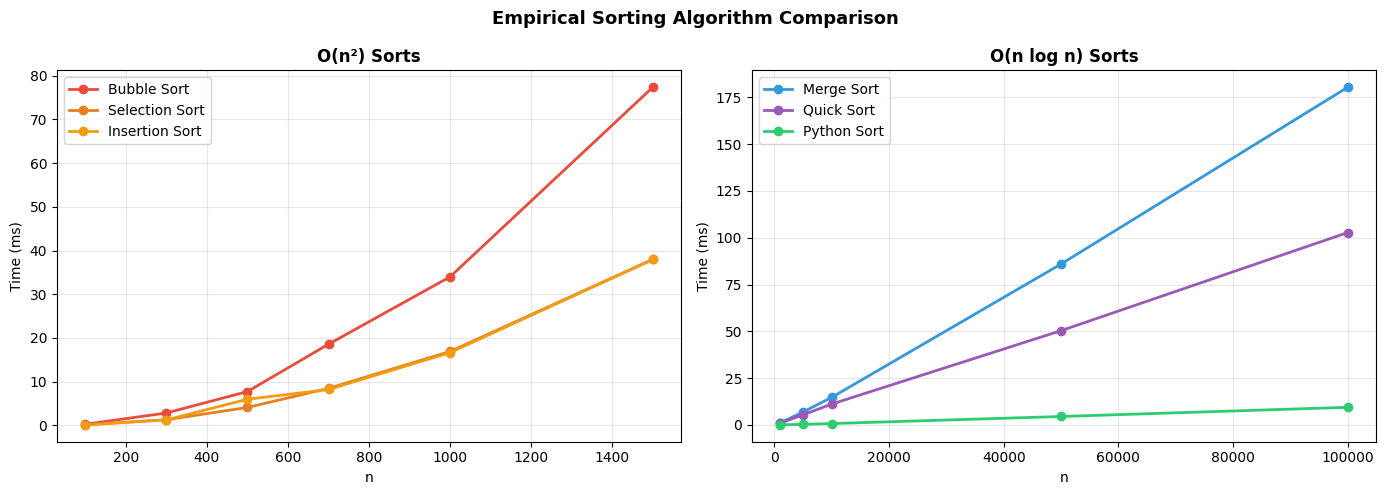

In [20]:
# === OPTIONAL DEMO — not assessed; for intuition only =======================
# Run the cell to compare runtimes. You do not need to understand every line.
# =============================================================================

# ---------------------------------------------------------------------------
# Time sorting functions on random lists of different lengths.
# Small n for slow O(n²) sorts; larger n for O(n log n) sorts.
# ---------------------------------------------------------------------------
import time

def time_sort(sort_fn, arr, reps=3):
    """Return best wall-clock time in milliseconds over `reps` runs."""
    best = float("inf")
    for _ in range(reps):
        data = arr.copy()
        start = time.perf_counter()
        sort_fn(data)  # return value ignored — we only care how long it takes
        elapsed = (time.perf_counter() - start) * 1000
        best = min(best, elapsed)
    return best


# Thin wrappers so every sort_fn has the same signature: one list argument
def bubble_sort_w(arr):
    bubble_sort(arr)


def selection_sort_w(arr):
    selection_sort(arr)


def insertion_sort_w(arr):
    insertion_sort(arr)


def merge_sort_w(arr):
    merge_sort(arr)


def quick_sort_w(arr):
    quick_sort(arr)


def python_sort_w(arr):
    arr.sort()  # in-place; Timsort under the hood in CPython


quadratic_sizes = [100, 300, 500, 700, 1000, 1500]
nlogn_sizes = [1000, 5000, 10000, 50000, 100000]

results_q = {fn.__name__: [] for fn in [bubble_sort_w, selection_sort_w, insertion_sort_w]}
results_n = {fn.__name__: [] for fn in [merge_sort_w, quick_sort_w, python_sort_w]}

print("Timing O(n²) algorithms...")
for n in quadratic_sizes:
    arr = [random.randint(1, 10000) for _ in range(n)]
    for fn in [bubble_sort_w, selection_sort_w, insertion_sort_w]:
        results_q[fn.__name__].append(time_sort(fn, arr))
    print(f"  n={n} done")

print("Timing O(n log n) algorithms...")
for n in nlogn_sizes:
    arr = [random.randint(1, 10000) for _ in range(n)]
    for fn in [merge_sort_w, quick_sort_w, python_sort_w]:
        results_n[fn.__name__].append(time_sort(fn, arr))
    print(f"  n={n} done")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

colours_q = {"bubble_sort_w": "#e74c3c", "selection_sort_w": "#e67e22", "insertion_sort_w": "#f39c12"}
for name, times in results_q.items():
    ax1.plot(
        quadratic_sizes,
        times,
        "o-",
        color=colours_q[name],
        linewidth=2,
        label=name.replace("_w", "").replace("_", " ").title(),
    )
ax1.set_xlabel("n")
ax1.set_ylabel("Time (ms)")
ax1.set_title("O(n²) Sorts", fontweight="bold")
ax1.legend()
ax1.grid(True, alpha=0.3)

colours_n = {"merge_sort_w": "#3498db", "quick_sort_w": "#9b59b6", "python_sort_w": "#2ecc71"}
for name, times in results_n.items():
    ax2.plot(
        nlogn_sizes,
        times,
        "o-",
        color=colours_n[name],
        linewidth=2,
        label=name.replace("_w", "").replace("_", " ").title(),
    )
ax2.set_xlabel("n")
ax2.set_ylabel("Time (ms)")
ax2.set_title("O(n log n) Sorts", fontweight="bold")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle("Empirical sorting comparison (optional demo)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


### 1.9 Pourquoi O(n log n) apparaît si souvent (enrichissement optionnel)

**Fait (vous pouvez l'utiliser sans la preuve) :** tout algorithme de tri qui n'apprend sur les données qu'en **comparant** des paires d'éléments nécessite **de l'ordre de n log n** comparaisons dans le pire cas lorsque toutes les permutations sont possibles.

**Intuition :** il y a **n!** façons d'ordonner n éléments distincts ; chaque comparaison donne au plus un bit d'information « dans quel ordre suis-je ? ». Réduire les n! possibilités à une seule ordering demande environ **log(n!)** étapes, qui croît comme **n log n**.

**Conclusion :** les algorithmes de type fusion et le Timsort de Python sont dans la bonne classe de complexité pour le tri par comparaison général. **On ne peut pas battre n log n** en ne se basant que sur des comparaisons. Des tris linéaires existent uniquement si l'on ajoute des **hypothèses supplémentaires** (par exemple des entiers dans un intervalle borné — idées de comptage / radix — pas au programme cette semaine).

Si cette section vous paraît abstraite, **revenez-y après** avoir implémenté le tri fusion ; c'est suffisant pour le cœur du cours.

### 1.10 Tri en Python — API intégrée

Dans le code courant vous appellerez presque toujours **`sorted()`** ou **`.sort()`** au lieu d'écrire tri fusion vous-même. Les deux utilisent **Timsort** (stable, efficace sur données partiellement triées, O(n log n) au pire).

| Function | Modifies original? | Returns |
|----------|--------------------|--------|
| `lst.sort()` | Yes (in-place) | `None` |
| `sorted(lst)` | No | New list |

**Paramètres :**

- `key=func` — comparer en utilisant `func(item)` (par exemple trier par note, ou `str.lower` pour des mots insensibles à la casse)
- `reverse=True` — du plus grand au plus petit

**`bisect` module** — recherche binaire sur une liste triée en O(log n) :

```python
import bisect
arr = [1, 3, 5, 7, 9]
i = bisect.bisect_left(arr, 5)   # returns 2
bisect.insort(arr, 6)            # inserts 6 in sorted position
```

In [21]:
# Examples: built-in sorting and bisect (binary search helper in the standard library)

import bisect

# ── sorted() vs list.sort() ──────────────────────────────────────────────
data = [3, 1, 4, 1, 5, 9, 2, 6]

out = sorted(data)              # new list; `data` unchanged
print("sorted():    ", out)
print("original:    ", data)

data.sort(reverse=True)         # in-place, descending; returns None
print("after .sort():", data)

# ── Custom key ───────────────────────────────────────────────────────────
words = ["Banana", "apple", "Cherry", "date"]
print("\nCase-insensitive:", sorted(words, key=str.lower))

students = [
    {"name": "Alice", "grade": 88},
    {"name": "Bob", "grade": 95},
    {"name": "Carol", "grade": 88},
]
by_grade = sorted(students, key=lambda s: (-s["grade"], s["name"]))
print("By grade desc, name asc:")
for s in by_grade:
    print(f"  {s['name']} {s['grade']}")

# ── bisect: binary search on a sorted list ────────────────────────────────
arr = [1, 3, 5, 7, 9]
i = bisect.bisect_left(arr, 5)
print(f"\nbisect_left([1,3,5,7,9], 5) = {i}  → arr[{i}] = {arr[i]}")

bisect.insort(arr, 6)
print("After insort(6):", arr)


sorted():     [1, 1, 2, 3, 4, 5, 6, 9]
original:     [3, 1, 4, 1, 5, 9, 2, 6]
after .sort(): [9, 6, 5, 4, 3, 2, 1, 1]

Case-insensitive: ['apple', 'Banana', 'Cherry', 'date']
By grade desc, name asc:
  Bob 95
  Alice 88
  Carol 88

bisect_left([1,3,5,7,9], 5) = 2  → arr[2] = 5
After insort(6): [1, 3, 5, 6, 7, 9]


---

## Partie 2 : Exercices

---

### Exercice 1 — Tri à bulles avec optimisation d'arrêt anticipé

Implémentez le tri à bulles avec l'optimisation d'arrêt anticipé (arrêter dès qu'une passe complète n'a produit aucun échange). Démontrez qu'il s'exécute en O(n) sur un tableau déjà trié en comptant les comparaisons.

In [22]:
def bubble_sort_optimised(arr):
    """
    Bubble Sort with early-exit on a full pass with no swaps.
    Returns (sorted_arr, num_comparisons).

    Best case O(n): one pass, n-1 comparisons, then we stop.
    """
    n = len(arr)
    comparisons = 0

    for i in range(n):
        swapped = False
        for j in range(0, n - i - 1):
            comparisons += 1  # count every neighbour comparison we attempt
            if arr[j] > arr[j + 1]:
                arr[j], arr[j + 1] = arr[j + 1], arr[j]
                swapped = True
        if not swapped:
            break

    return arr, comparisons


n = 20
sorted_input = list(range(n))
random_input = [random.randint(1, 100) for _ in range(n)]
reverse_input = list(range(n, 0, -1))

_, c_sorted = bubble_sort_optimised(sorted_input)
_, c_random = bubble_sort_optimised(random_input)
_, c_reverse = bubble_sort_optimised(reverse_input)

print(f"n = {n}")
print(f"Already sorted (best case):  {c_sorted} comparisons  (expected: n-1 = {n - 1})")
print(f"Random array:                {c_random} comparisons")
print(f"Reverse sorted (worst case): {c_reverse} comparisons  (expected: n(n-1)/2 = {n * (n - 1) // 2})")


n = 20
Already sorted (best case):  19 comparisons  (expected: n-1 = 19)
Random array:                187 comparisons
Reverse sorted (worst case): 190 comparisons  (expected: n(n-1)/2 = 190)


### Exercice 2 — Trier une liste de dictionnaires par clé

Étant donnée une liste de dictionnaires d'étudiants, triez-la :
1. Par note (descendant).
2. Par nom (ascendant), mais seulement parmi les étudiants ayant la même note.

Utilisez `sorted` de Python avec une clé personnalisée, puis implémentez-le manuellement en utilisant le tri par insertion.

In [23]:
# --- Exercise 2: sort dicts by grade (desc) then name (asc) ---
# Two approaches: stable two-pass vs one tuple key

students = [
    {'name': 'Alice',   'grade': 88},
    {'name': 'Bob',     'grade': 95},
    {'name': 'Charlie', 'grade': 88},
    {'name': 'Diana',   'grade': 72},
    {'name': 'Eve',     'grade': 95},
    {'name': 'Frank',   'grade': 65},
    {'name': 'Grace',   'grade': 72},
]

# ---- Built-in sort: grade descending, then name ascending ----
# Python's sorted() is stable, so we can sort by name first, then by grade.
by_name  = sorted(students, key=lambda s: s['name'])
by_grade = sorted(by_name, key=lambda s: s['grade'], reverse=True)

print("Sorted by grade (desc), then name (asc) — Python built-in:")
for s in by_grade:
    print(f"  {s['name']:<10} grade={s['grade']}")

# ---- Manual insertion sort on grade, then name ----
def insertion_sort_dicts(arr, key, reverse=False):
    """Insertion sort a list of dicts by key. Stable. O(n²)."""
    for i in range(1, len(arr)):
        current = arr[i]
        j = i - 1
        if reverse:
            while j >= 0 and arr[j][key] < current[key]:
                arr[j + 1] = arr[j]
                j -= 1
        else:
            while j >= 0 and arr[j][key] > current[key]:
                arr[j + 1] = arr[j]
                j -= 1
        arr[j + 1] = current
    return arr

manual = insertion_sort_dicts(students, 'name', reverse=False)
manual = insertion_sort_dicts(manual, 'grade', reverse=True)

print("\nSorted by grade (desc), then name (asc) — manual insertion sort:")
for s in manual:
    print(f"  {s['name']:<10} grade={s['grade']}")

assert [(s['name'], s['grade']) for s in by_grade] == [(s['name'], s['grade']) for s in manual]
print("\nBoth methods produce identical results.")

Sorted by grade (desc), then name (asc) — Python built-in:
  Bob        grade=95
  Eve        grade=95
  Alice      grade=88
  Charlie    grade=88
  Diana      grade=72
  Grace      grade=72
  Frank      grade=65

Sorted by grade (desc), then name (asc) — manual insertion sort:
  Bob        grade=95
  Eve        grade=95
  Alice      grade=88
  Charlie    grade=88
  Diana      grade=72
  Grace      grade=72
  Frank      grade=65

Both methods produce identical results.


### Exercice 3 — Recherche binaire : itérative et récursive

Implémentez la recherche binaire de façon itérative et de façon récursive.

> **Lien avec la Semaine 7 :** durant la Semaine 7 vous avez implémenté la recherche binaire récursive comme exercice de récursion. Ici l'accent change sur le contexte de l'algorithme de recherche — compromis itératif vs récursif (complexité spatiale) et le module pratique `bisect`. Vérifiez qu'elles produisent des résultats identiques. Discutez de la différence de complexité spatiale.

In [24]:
# --- Exercise 3: binary search iterative + recursive ---
# Preconditions: arr sorted ascending; return index or -1

def binary_search_iterative(arr, target):
    """
    Iterative binary search.
    Space: O(1) — only variables low, mid, high; no call stack overhead.
    """
    low, high = 0, len(arr) - 1
    while low <= high:
        mid = (low + high) // 2
        if arr[mid] == target:
            return mid
        elif arr[mid] < target:
            low = mid + 1
        else:
            high = mid - 1
    return -1


def binary_search_recursive(arr, target, low=None, high=None):
    """
    Recursive binary search.
    Space: O(log n) — each recursive call adds a stack frame.
    """
    if low is None:
        low, high = 0, len(arr) - 1

    if low > high:
        return -1           # Base case: target not found

    mid = (low + high) // 2
    if arr[mid] == target:
        return mid
    elif arr[mid] < target:
        return binary_search_recursive(arr, target, mid + 1, high)   # Recurse right
    else:
        return binary_search_recursive(arr, target, low, mid - 1)    # Recurse left


test_arr2 = sorted([random.randint(1, 200) for _ in range(50)])
queries2  = [test_arr2[5], test_arr2[25], test_arr2[49], -1, 999]

print(f"{'Target':<8} {'Iterative':>10} {'Recursive':>10} {'Expected':>10} {'Match?':>8}")
print("-" * 50)
for q in queries2:
    it = binary_search_iterative(test_arr2, q)
    rc = binary_search_recursive(test_arr2, q)
    try:
        expected = test_arr2.index(q)
    except ValueError:
        expected = -1
    match = "YES" if it == rc == expected else "NO"
    print(f"{q:<8} {it:>10} {rc:>10} {expected:>10} {match:>8}")

Target    Iterative  Recursive   Expected   Match?
--------------------------------------------------
23                5          5          5      YES
106              25         25         25      YES
197              49         49         49      YES
-1               -1         -1         -1      YES
999              -1         -1         -1      YES


### Exercice 4 — Recherche dans un tableau trié tourné *(Challenge)*

Un **tableau trié tourné** est un tableau trié qui a été cycliquement décalé d'un certain montant. Par exemple : `[4, 5, 6, 7, 0, 1, 2]` est le tableau `[0, 1, 2, 4, 5, 6, 7]` tourné de 4 positions.

Implémentez un algorithme en O(log n) pour trouver une valeur cible dans un tel tableau.

> **C'est un exercice plus difficile.** Essayez-le après avoir terminé les Exercices 1–3. Il nécessite une insight non évidente à propos de la recherche binaire et n'est pas requis pour l'examen de base.

In [25]:
# --- Exercise 4: rotated sorted array ---
# One rotation: was sorted, then left chunk moved to the right

def search_rotated(arr, target):
    """
    Find target in a rotated sorted array — O(log n).

    Key insight: after computing mid, at least one of the two halves
    [low..mid] or [mid..high] must be sorted. We can determine which half
    is sorted by comparing arr[low] with arr[mid], and then check
    whether the target lies in the sorted half.

    Returns the index of target, or -1 if not present.
    """
    low, high = 0, len(arr) - 1

    while low <= high:
        mid = (low + high) // 2

        if arr[mid] == target:
            return mid

        # Determine which half is contiguously sorted
        if arr[low] <= arr[mid]:             # Left half is sorted
            if arr[low] <= target < arr[mid]:
                high = mid - 1              # Target must be in the left half
            else:
                low = mid + 1               # Target must be in the right half
        else:                               # Right half is sorted
            if arr[mid] < target <= arr[high]:
                low = mid + 1               # Target must be in the right half
            else:
                high = mid - 1              # Target must be in the left half

    return -1


# ---- Tests ----
test_cases_rotated = [
    ([4, 5, 6, 7, 0, 1, 2], 0, 4),
    ([4, 5, 6, 7, 0, 1, 2], 3, -1),
    ([1],                    0, -1),
    ([1],                    1, 0),
    ([3, 1],                 1, 1),
    ([5, 1, 3],              3, 2),
]

print(f"{'Array':<30} {'Target':>8} {'Expected':>10} {'Result':>8} {'Pass?':>7}")
print("-" * 65)
for arr_r, tgt, expected_idx in test_cases_rotated:
    result = search_rotated(arr_r, tgt)
    status = "PASS" if result == expected_idx else "FAIL"
    print(f"{str(arr_r):<30} {tgt:>8} {expected_idx:>10} {result:>8} {status:>7}")

Array                            Target   Expected   Result   Pass?
-----------------------------------------------------------------
[4, 5, 6, 7, 0, 1, 2]                 0          4        4    PASS
[4, 5, 6, 7, 0, 1, 2]                 3         -1       -1    PASS
[1]                                   0         -1       -1    PASS
[1]                                   1          0        0    PASS
[3, 1]                                1          1        1    PASS
[5, 1, 3]                             3          2        2    PASS


### Exercice 5 — Compter les inversions en utilisant le tri fusion *(Challenge)*

Une **inversion** dans un tableau est une paire d'indices (i, j) telle que i < j mais arr[i] > arr[j].

Le nombre d'inversions mesure à quel point un tableau est éloigné d'un tableau trié. Un tableau entièrement trié a 0 inversion ; un tableau complètement inversé a n(n-1)/2 inversions.

L'approche naïve en O(n²) vérifie toutes les paires. On peut compter les inversions en **O(n log n)** en modifiant le tri fusion : chaque fois que l'on prend un élément du sous-tableau droit avant d'avoir fini le gauche, il est en désordre par rapport à tous les éléments restants du gauche.

> **C'est un exercice plus difficile.** Il requiert une compréhension solide du fonctionnement interne de l'étape de fusion (§1.5). Essayez-le après l'Exercice 4, ou revenez-y après la Semaine 9.

In [26]:
# --- Exercise 5: count inversions with merge-sort idea ---
# Inversion = pair (i,j) with i<j but arr[i]>arr[j]

def count_inversions(arr):
    """
    Count the number of inversions in arr using a modified Merge Sort.

    Time: O(n log n)
    Returns (sorted_arr, inversion_count).

    Key insight: during the merge step, if we pick arr_right[j] before arr_left[i],
    then arr_right[j] forms an inversion with arr_left[i], arr_left[i+1], ..., arr_left[end].
    That is (len(left) - i) inversions for this single pick.
    """
    if len(arr) <= 1:
        return arr, 0

    mid = len(arr) // 2
    left,  inv_left  = count_inversions(arr[:mid])
    right, inv_right = count_inversions(arr[mid:])

    # Merge and count split inversions
    merged = []
    inv_split = 0
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] <= right[j]:
            merged.append(left[i])
            i += 1
        else:
            # right[j] is smaller than left[i..end] — those are inversions
            inv_split += len(left) - i
            merged.append(right[j])
            j += 1

    merged.extend(left[i:])
    merged.extend(right[j:])

    total_inv = inv_left + inv_right + inv_split
    return merged, total_inv


def count_inversions_brute(arr):
    """O(n²) inversion count for correctness verification."""
    count = 0
    n = len(arr)
    for i in range(n):
        for j in range(i + 1, n):
            if arr[i] > arr[j]:
                count += 1
    return count


# ---- Test cases ----
tests_inv = [
    [1, 2, 3, 4, 5],      # 0 inversions (sorted)
    [5, 4, 3, 2, 1],      # 10 inversions (reversed)
    [2, 4, 1, 3, 5],      # 3 inversions
    [6, 5, 4, 3, 2, 1],   # 15 inversions
]

print(f"{'Array':<30} {'Merge Sort Count':>18} {'Brute Count':>13} {'Match?':>8}")
print("-" * 72)
for arr_t in tests_inv:
    _, ms_count = count_inversions(arr_t)
    br_count    = count_inversions_brute(arr_t)
    match = "YES" if ms_count == br_count else "NO"
    print(f"{str(arr_t):<30} {ms_count:>18} {br_count:>13} {match:>8}")

Array                            Merge Sort Count   Brute Count   Match?
------------------------------------------------------------------------
[1, 2, 3, 4, 5]                                 0             0      YES
[5, 4, 3, 2, 1]                                10            10      YES
[2, 4, 1, 3, 5]                                 3             3      YES
[6, 5, 4, 3, 2, 1]                             15            15      YES


### Exercice 2.6 — Tri de Shell (optionnel)

**Optionnel / extension :** le tri de Shell n'est **pas** requis pour les objectifs principaux de la semaine. Considérez cet exercice comme **un entraînement supplémentaire** si vous voulez un tri classique à séquence d'écarts au-delà du tri par insertion.

**Partie A.** Implémentez `shell_sort(arr, gaps=None)` en utilisant la séquence d'écarts de Shell (n//2, n//4, …, 1).

**Partie B.** Essayez une autre séquence d'écarts — **celle de Hibbard** (les écarts sont 2ᵏ − 1 : 1, 3, 7, 15, …). En quelques mots, laquelle a tendance à faire moins de comparaisons sur la même entrée ?

**Partie C.** *(Exploration seulement — code non critique pour l'examen.)* Sur un tableau aléatoire de 5000 éléments, mesurez et comparez le temps d'exécution (ou simplement le nombre de comparaisons) pour `insertion_sort` (de la section 1.4), `shell_sort` avec les écarts de Shell, et `shell_sort` avec les écarts de Hibbard. Un petit tableau imprimé suffit. Vous n'avez pas besoin d'un code de benchmarking sophistiqué.

In [ ]:
# Exercise 2.6 — Shell Sort (optional)
import time
import random


def shell_sort_shells(arr):
    """Shell sort using Shell's gap sequence: n//2, n//4, ... down to 1.

    For each gap, we do an insertion-sort style pass that compares elements
    `gap` apart — that lets values "leap" faster than ordinary insertion sort.
    """
    n = len(arr)
    gap = n // 2
    while gap > 0:
        # Insertion sort on indices ..., i-gap, i, i+gap, ... (stride = gap)
        for i in range(gap, n):
            temp = arr[i]
            j = i
            while j >= gap and arr[j - gap] > temp:
                arr[j] = arr[j - gap]
                j -= gap
            arr[j] = temp
        gap //= 2
    return arr


def hibbard_gaps(n):
    """Return Hibbard gaps 2^k - 1 that are <= n, largest first (e.g. ... 7, 3, 1)."""
    gaps = []
    k = 1
    while True:
        g = (1 << k) - 1  # 2^k - 1
        if g > n:
            break
        gaps.append(g)
        k += 1
    return list(reversed(gaps)) if gaps else [1]


def shell_sort_hibbard(arr):
    """Same idea as shell_sort_shells but with Hibbard's gap sequence."""
    for gap in hibbard_gaps(len(arr)):
        for i in range(gap, len(arr)):
            temp = arr[i]
            j = i
            while j >= gap and arr[j - gap] > temp:
                arr[j] = arr[j - gap]
                j -= gap
            arr[j] = temp
    return arr


test_data = [54, 26, 93, 17, 77, 31, 44, 55, 20]
assert shell_sort_shells(test_data) == sorted(test_data), "Shell gaps: sort mismatch"
assert shell_sort_hibbard(test_data) == sorted(test_data), "Hibbard gaps: sort mismatch"
print("Correctness OK")

# Part C: optional timing — uses insertion_sort from section 1.4 (same notebook)
random.seed(0)
n = 5000
data = [random.randint(0, 10_000) for _ in range(n)]


def time_it(fn, arr, reps=5):
    best = float("inf")
    for _ in range(reps):
        a = arr.copy()
        t0 = time.perf_counter()
        fn(a)
        best = min(best, time.perf_counter() - t0)
    return best * 1000


print(f"{'Algorithm':25s} {'Time (ms)':>10}")
print("-" * 37)
print(f"{'Insertion sort':25s} {time_it(insertion_sort, data):>10.2f}")
print(f"{'Shell (Shell gaps)':25s} {time_it(shell_sort_shells, data):>10.2f}")
print(f"{'Shell (Hibbard gaps)':25s} {time_it(shell_sort_hibbard, data):>10.2f}")
